# Tutorial 2: Batching coalition evaluation

Vision models are expensive to evaluate, and an explanation may require hundreds or thousands of coalition evaluations.
By default, `ImageImputer` assembles all masked images into one tensor and performs a single forward pass.
For large grids or models this can exhaust available memory.

The `batch_size` parameter on `ImageImputer` (and `ImageExplainer`) splits coalitions into chunks of at most `batch_size`,
calls the architecture once per chunk, and concatenates the results. The output is numerically equivalent to the unbatched
path up to floating-point rounding (on the order of 10⁻⁵), at the cost of a small overhead per chunk.


In [30]:
from __future__ import annotations

import time
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from torchvision import models, transforms

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


image shape: (224, 224, 3)


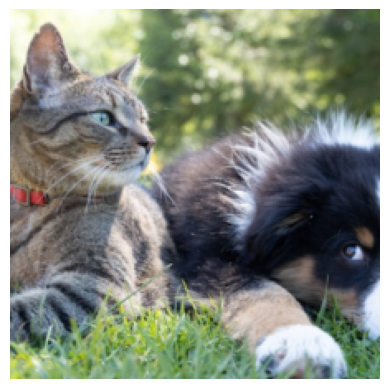

In [31]:
URL = (
    "https://images.unsplash.com/photo-1623387641168-d9803ddd3f35?"
    "q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0"
)
raw = Image.open(BytesIO(requests.get(URL, timeout=30).content)).convert("RGB")
resize = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
pil_image = resize(raw)
image = np.array(pil_image)
print("image shape:", image.shape)
plt.imshow(image)
plt.axis("off")
plt.show()

## A ResNet18 wrapper to use throughout


In [32]:
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights).eval().to(device)
preprocess = transforms.Compose([transforms.ToTensor(), weights.transforms()])

with torch.no_grad():
    class_id = int(resnet(preprocess(pil_image).unsqueeze(0).to(device)).argmax(-1).item())
print("class:", class_id, weights.meta["categories"][class_id])


def resnet_model(batch_hwc: np.ndarray) -> np.ndarray:
    pils = [Image.fromarray(arr.astype(np.uint8)) for arr in batch_hwc]
    tensors = torch.stack([preprocess(im) for im in pils]).to(device)
    with torch.no_grad():
        logits = resnet(tensors)
    return logits[:, class_id].cpu().numpy()

class: 281 tabby


## Demo 1: Numerical equivalence across batch sizes

The image, masker, and player strategy are held fixed. Only `batch_size` varies. Results are **numerically equivalent up to floating-point rounding**.

Small differences (on the order of 10⁻⁵) can appear because floating-point addition is not associative: grouping the same model evaluations into different batch sizes changes the summation order inside the neural network, so intermediate results round differently. Setting `batch_size=1024` covers all 200 coalitions in a single chunk, the same as `None`, and therefore produces an exact zero difference. Every other size introduces small hardware-level rounding noise.


In [33]:
from shapiq.vision import ImageImputer, ResNetArchitecture, SuperpixelStrategy
from shapiq.vision.masking import MeanColorMasking

player_strategy = SuperpixelStrategy(n_segments=10)
n_coalitions = 200
rng = np.random.default_rng(0)
coalitions = rng.integers(0, 2, size=(n_coalitions, 10)).astype(bool)


def values_with_batch(batch_size):
    arch = ResNetArchitecture(model=resnet_model, masking_strategy=MeanColorMasking())
    imp = ImageImputer(
        architecture=arch,
        image=image,
        player_strategy=player_strategy,
        batch_size=batch_size,
        normalize=False,
    )
    return imp.value_function(coalitions)


v_full = values_with_batch(None)
for bs in [1, 4, 16, 64, 1024]:
    v_bs = values_with_batch(bs)
    assert np.allclose(v_full, v_bs, atol=1e-4), f"mismatch at batch_size={bs}"
    print(
        f"batch_size={bs:>4} → output matches unbatched (max |diff| = {np.max(np.abs(v_full - v_bs)):.2e})"
    )

batch_size=   1 → output matches unbatched (max |diff| = 3.43e-05)
batch_size=   4 → output matches unbatched (max |diff| = 3.62e-05)
batch_size=  16 → output matches unbatched (max |diff| = 2.38e-05)
batch_size=  64 → output matches unbatched (max |diff| = 2.38e-05)
batch_size=1024 → output matches unbatched (max |diff| = 0.00e+00)


## Demo 2: Timing vs. batch size

Smaller batches reduce peak memory but incur additional overhead per chunk. On GPU there is a sweet spot where the hardware can fully exploit parallelism. Very small batches under-utilise the device, and the optimal size depends on model size and available VRAM.

On **CPU** the picture is different: forward passes are sequential regardless of batch size, and the per-chunk overhead is small relative to inference time. Timings across batch sizes can therefore be noisy and roughly flat.


batch_size=    1  wall=3.908s
batch_size=    2  wall=5.369s
batch_size=    4  wall=4.364s
batch_size=    8  wall=4.176s
batch_size=   16  wall=4.999s
batch_size=   32  wall=4.473s
batch_size=   64  wall=4.188s
batch_size=  128  wall=4.276s
batch_size= None  wall=4.280s


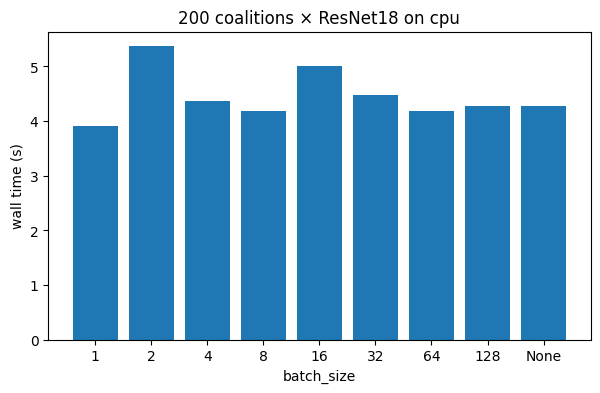

In [34]:
def time_batch(batch_size, n_repeat=3):
    timings = []
    for _ in range(n_repeat):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        values_with_batch(batch_size)
        if device.type == "cuda":
            torch.cuda.synchronize()
        timings.append(time.perf_counter() - t0)
    return min(timings)


batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, None]
times = [time_batch(bs) for bs in batch_sizes]
for bs, t in zip(batch_sizes, times, strict=False):
    print(f"batch_size={bs!s:>5}  wall={t:.3f}s")

fig, ax = plt.subplots(figsize=(7, 4))
labels = [str(bs) if bs is not None else "None" for bs in batch_sizes]
ax.bar(labels, times)
ax.set_xlabel("batch_size")
ax.set_ylabel("wall time (s)")
ax.set_title(f"200 coalitions × ResNet18 on {device.type}")
plt.show()

## Demo 3: Memory comparison (CUDA only)

With a CUDA device available, the peak-memory savings from smaller batches are directly measurable. Without CUDA this cell is skipped.


In [28]:
if device.type == "cuda":
    for bs in [None, 64, 16, 4, 1]:
        torch.cuda.reset_peak_memory_stats(device)
        values_with_batch(bs)
        peak_mb = torch.cuda.max_memory_allocated(device) / 1024**2
        print(f"batch_size={bs!s:>4}  peak GPU memory ≈ {peak_mb:7.1f} MB")
else:
    print("No CUDA device available — skipping GPU memory measurement.")

No CUDA device available — skipping GPU memory measurement.


## Demo 4: End-to-end through the explainer

`batch_size` can be passed directly to `ImageExplainer`, which forwards it to the underlying imputer. The resulting explanations are numerically identical to the unbatched case, but large budgets become feasible even on GPUs with limited memory.


In [29]:
from shapiq import ImageExplainer

arch_a = ResNetArchitecture(model=resnet_model, masking_strategy=MeanColorMasking())
exp_a = ImageExplainer(architecture=arch_a, data=image, batch_size=None, random_state=0)
iv_a = exp_a.explain_function(image, budget=128)

arch_b = ResNetArchitecture(model=resnet_model, masking_strategy=MeanColorMasking())
exp_b = ImageExplainer(architecture=arch_b, data=image, batch_size=16, random_state=0)
iv_b = exp_b.explain_function(image, budget=128)

diff = np.max(np.abs(iv_a.values - iv_b.values))
print(f"max |Δ Shapley| between batch_size=None and batch_size=16: {diff:.2e}")

max |Δ Shapley| between batch_size=None and batch_size=16: 0.00e+00


## Choosing a batch size

A few guidelines based on typical hardware:

| Setting | Suggested `batch_size` |
|---|---|
| CPU debugging | `1`–`4` |
| Consumer GPU (8–12 GB) with ViT-B | `16`–`32` |
| Large GPU (24 GB+) with a small model | `None` |
| Latent-space ViT with large grids (≥14×14 = 196 players) | Set explicitly; coalitions can grow into the thousands |

If the forward pass runs out of memory, halving the batch size is usually sufficient. The resulting explanations are unchanged.